In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving marketing_funnel_dataset.csv to marketing_funnel_dataset.csv


In [3]:
df = pd.read_csv("marketing_funnel_dataset.csv")

In [4]:
df.head()

,record_id,date,campaign_name,channel,device,country,sessions,bounce_rate_pct,avg_session_duration_sec,pages_per_session,leads,mqls,sqls,opportunities,customers,ad_spend_usd,revenue_usd,conversion_rate_pct,cpl_usd,roas
0,1001,2026-01-01,Brand Awareness Q2,Organic Search,Tablet,Germany,181,32.7,54,6.22,8,3,1,1,0,0.00,0.00,4.42,0.00,NaN
1,1002,2026-01-01,Retargeting - Cart Abandoners,Referral,Desktop,Australia,172,68.6,316,6.17,11,5,3,2,1,17.52,148.40,6.40,1.59,8.47
2,1000,2026-01-01,Summer Sale 2026,Paid Search,Desktop,Germany,175,33.2,97,2.74,15,5,3,1,1,356.89,158.57,8.57,23.79,0.44
3,1008,2026-01-02,Brand Awareness Q2,Affiliate,Desktop,Germany,181,27.3,133,6.00,12,9,3,0,0,170.04,0.00,6.63,14.17,0.00
4,1006,2026-01-02,Holiday Teaser,Paid Search,Mobile,Australia,201,61.2,99,5.92,16,5,1,0,0,381.11,0.00,7.96,23.82,0.00


In [5]:
df.tail()

,record_id,date,campaign_name,channel,device,country,sessions,bounce_rate_pct,avg_session_duration_sec,pages_per_session,leads,mqls,sqls,opportunities,customers,ad_spend_usd,revenue_usd,conversion_rate_pct,cpl_usd,roas
791,1791,2026-06-29,Retargeting - Cart Abandoners,Email,Tablet,Australia,174,27.4,332,5.55,15,10,4,2,1,7.16,337.62,8.62,0.48,47.15
792,1792,2026-06-30,Holiday Teaser,Organic Search,Mobile,India,169,60.7,385,3.41,8,4,0,0,0,0.00,0.00,4.73,0.00,NaN
793,1794,2026-06-30,New Customer Promo,Affiliate,Mobile,Canada,172,28.8,221,2.32,8,3,2,2,0,182.24,0.00,4.65,22.78,0.00
794,1795,2026-06-30,Newsletter Signup Drive,Social Media,Mobile,UAE,176,60.1,155,2.07,4,3,2,1,1,185.91,272.93,2.27,46.48,1.47
795,1793,2026-06-30,Spring Launch,Affiliate,Tablet,Canada,180,32.8,168,3.35,5,1,1,0,0,136.78,0.00,2.78,27.36,0.00


In [6]:
df.shape

(796, 20)

In [7]:
df.columns

Index(['record_id', 'date', 'campaign_name', 'channel', 'device', 'country',
       'sessions', 'bounce_rate_pct', 'avg_session_duration_sec',
       'pages_per_session', 'leads', 'mqls', 'sqls', 'opportunities',
       'customers', 'ad_spend_usd', 'revenue_usd', 'conversion_rate_pct',
       'cpl_usd', 'roas'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   record_id                 796 non-null    int64  
 1   date                      796 non-null    object 
 2   campaign_name             796 non-null    object 
 3   channel                   796 non-null    object 
 4   device                    796 non-null    object 
 5   country                   796 non-null    object 
 6   sessions                  796 non-null    int64  
 7   bounce_rate_pct           796 non-null    float64
 8   avg_session_duration_sec  796 non-null    int64  
 9   pages_per_session         796 non-null    float64
 10  leads                     796 non-null    int64  
 11  mqls                      796 non-null    int64  
 12  sqls                      796 non-null    int64  
 13  opportunities             796 non-null    int64  
 14  customers 

In [10]:
df.describe()

,record_id,sessions,bounce_rate_pct,avg_session_duration_sec,pages_per_session,leads,mqls,sqls,opportunities,customers,ad_spend_usd,revenue_usd,conversion_rate_pct,cpl_usd,roas
count,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,796.000000,570.000000
mean,1397.500000,163.351759,48.291583,210.742462,3.843756,8.905779,4.657035,2.201005,1.228643,0.520101,89.190264,141.246482,5.406244,15.774259,9.071140
std,229.929699,27.275753,12.710210,105.583722,1.549924,4.807480,2.999239,1.824997,1.320562,0.796753,109.899507,252.186829,2.705181,24.879673,27.370774
min,1000.000000,100.000000,25.000000,30.000000,1.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1198.750000,136.750000,37.300000,120.750000,2.557500,5.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.427500,0.000000,0.000000
50%,1397.500000,172.000000,49.200000,209.500000,3.790000,8.000000,4.000000,2.000000,1.000000,0.000000,15.775000,0.000000,5.135000,1.570000,0.000000
75%,1596.250000,182.250000,58.925000,300.000000,5.175000,12.000000,6.000000,3.000000,2.000000,1.000000,167.455000,236.785000,7.100000,25.387500,1.947500
max,1795.000000,224.000000,69.900000,399.000000,6.490000,27.000000,17.000000,11.000000,9.000000,6.000000,414.930000,2649.330000,15.820000,197.370000,353.240000


In [11]:
df.isnull().sum()

,0
record_id,0
date,0
campaign_name,0
channel,0
device,0
country,0
sessions,0
bounce_rate_pct,0
avg_session_duration_sec,0
pages_per_session,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["date"] = pd.to_datetime(df["date"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   record_id                 796 non-null    int64         
 1   date                      796 non-null    datetime64[ns]
 2   campaign_name             796 non-null    object        
 3   channel                   796 non-null    object        
 4   device                    796 non-null    object        
 5   country                   796 non-null    object        
 6   sessions                  796 non-null    int64         
 7   bounce_rate_pct           796 non-null    float64       
 8   avg_session_duration_sec  796 non-null    int64         
 9   pages_per_session         796 non-null    float64       
 10  leads                     796 non-null    int64         
 11  mqls                      796 non-null    int64         
 12  sqls                  

In [15]:
df.columns

Index(['record_id', 'date', 'campaign_name', 'channel', 'device', 'country',
       'sessions', 'bounce_rate_pct', 'avg_session_duration_sec',
       'pages_per_session', 'leads', 'mqls', 'sqls', 'opportunities',
       'customers', 'ad_spend_usd', 'revenue_usd', 'conversion_rate_pct',
       'cpl_usd', 'roas'],
      dtype='object')

In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 796
Columns: 20


In [17]:
df.dtypes

,0
record_id,int64
date,datetime64[ns]
campaign_name,object
channel,object
device,object
country,object
sessions,int64
bounce_rate_pct,float64
avg_session_duration_sec,int64
pages_per_session,float64


In [18]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
record_id,796.0,1397.5,1000.0,1198.75,1397.5,1596.25,1795.0,229.929699
date,796,2026-04-01 10:20:30.150753792,2026-01-01 00:00:00,2026-02-16 00:00:00,2026-04-01 12:00:00,2026-05-18 00:00:00,2026-06-30 00:00:00,NaN
sessions,796.0,163.351759,100.0,136.75,172.0,182.25,224.0,27.275753
bounce_rate_pct,796.0,48.291583,25.0,37.3,49.2,58.925,69.9,12.71021
avg_session_duration_sec,796.0,210.742462,30.0,120.75,209.5,300.0,399.0,105.583722
pages_per_session,796.0,3.843756,1.1,2.5575,3.79,5.175,6.49,1.549924
leads,796.0,8.905779,0.0,5.0,8.0,12.0,27.0,4.80748
mqls,796.0,4.657035,0.0,2.0,4.0,6.0,17.0,2.999239
sqls,796.0,2.201005,0.0,1.0,2.0,3.0,11.0,1.824997
opportunities,796.0,1.228643,0.0,0.0,1.0,2.0,9.0,1.320562


In [19]:
df["channel"].value_counts()

,count
channel,
Email,126
Direct,121
Social Media,120
Referral,111
Paid Search,109
Organic Search,105
Affiliate,104


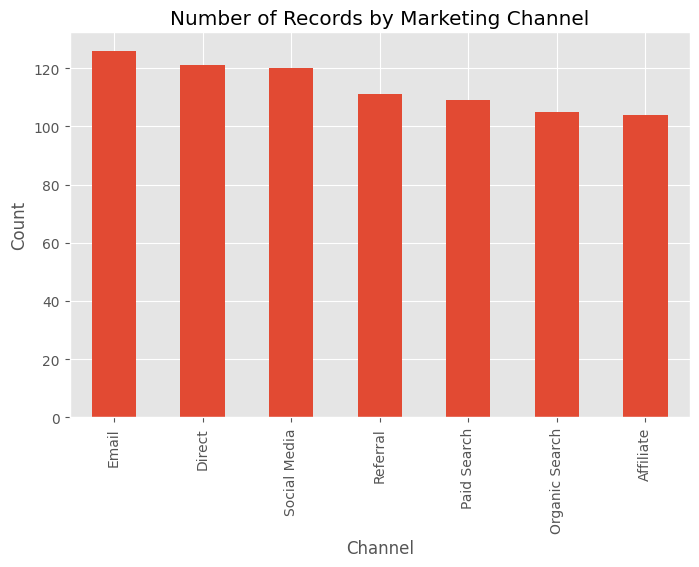

In [21]:
plt.figure(figsize=(8,5))

df["channel"].value_counts().plot(kind="bar")

plt.title("Number of Records by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Count")

# Save the chart as PNG
plt.savefig("channel_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
from google.colab import files

files.download("channel_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
df["device"].value_counts()

,count
device,
Mobile,284
Tablet,274
Desktop,238


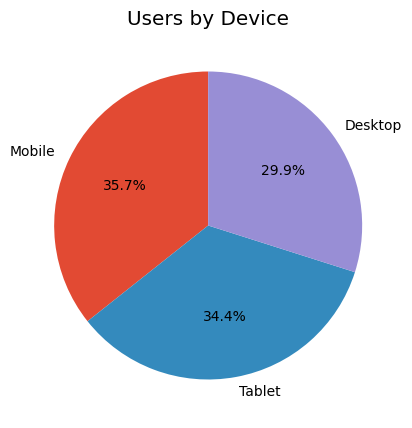

In [25]:
plt.figure(figsize=(6,5))

df["device"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Users by Device")

# Save the chart as PNG
plt.savefig("device_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
from google.colab import files

files.download("device_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# Count records by country
df["country"].value_counts()

,count
country,
UAE,126
Germany,125
Canada,119
USA,118
Australia,111
UK,100
India,97


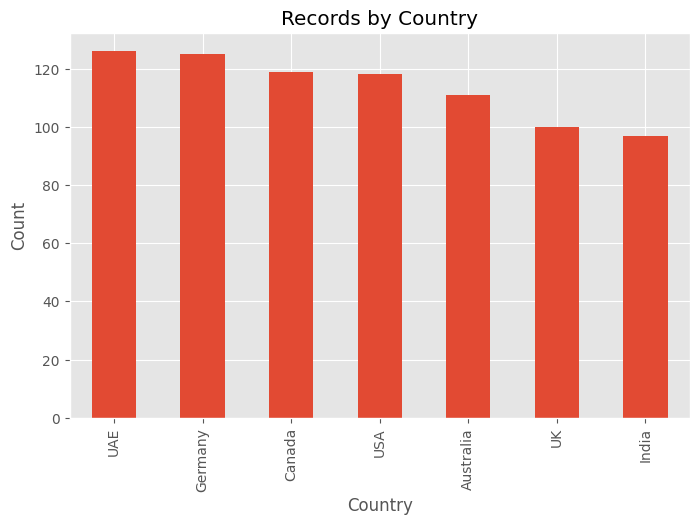

In [28]:
plt.figure(figsize=(8,5))

df["country"].value_counts().plot(kind="bar")

plt.title("Records by Country")
plt.xlabel("Country")
plt.ylabel("Count")

# Save chart
plt.savefig("country_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
from google.colab import files
files.download("country_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print("Total Sessions:", df["sessions"].sum())

Total Sessions: 130028


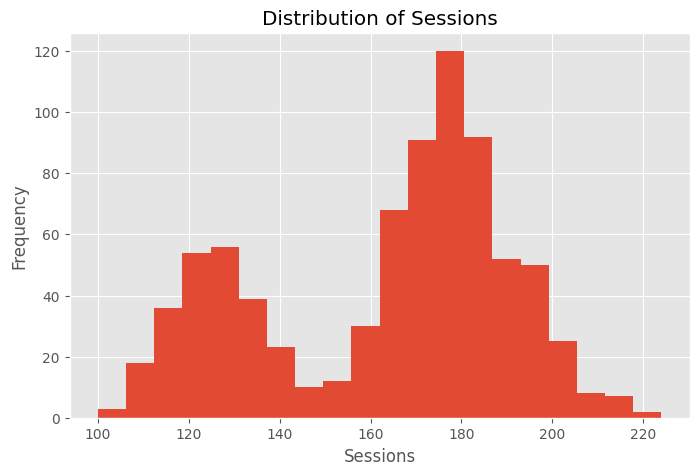

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df["sessions"], bins=20)

plt.title("Distribution of Sessions")
plt.xlabel("Sessions")
plt.ylabel("Frequency")

# Save chart
plt.savefig("sessions_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
from google.colab import files
files.download("sessions_histogram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
print("Total Revenue (USD):", round(df["revenue_usd"].sum(),2))

Total Revenue (USD): 112432.2


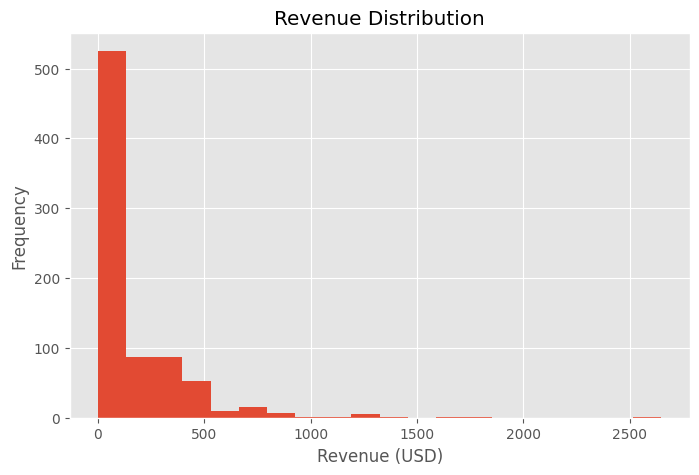

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["revenue_usd"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")

# Save chart
plt.savefig("revenue_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
from google.colab import files
files.download("revenue_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

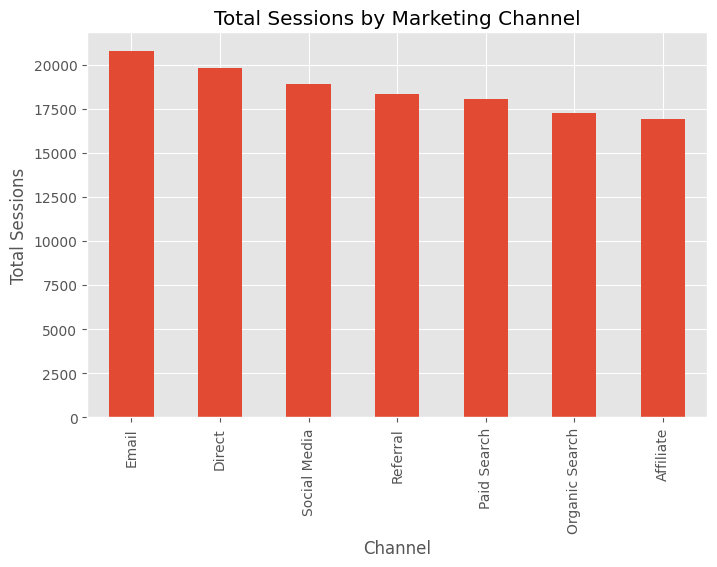

In [36]:
channel_sessions = df.groupby("channel")["sessions"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

channel_sessions.plot(kind="bar")

plt.title("Total Sessions by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Total Sessions")

# Save chart
plt.savefig("channel_sessions.png", dpi=300, bbox_inches="tight")

plt.show()

In [37]:
from google.colab import files
files.download("channel_sessions.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

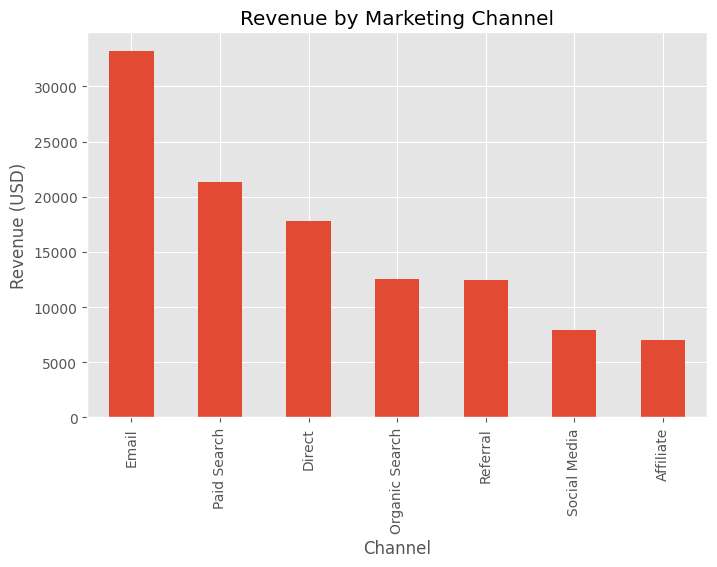

In [38]:
channel_revenue = df.groupby("channel")["revenue_usd"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

channel_revenue.plot(kind="bar")

plt.title("Revenue by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue (USD)")

# Save chart
plt.savefig("channel_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

In [39]:
from google.colab import files
files.download("channel_revenue.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

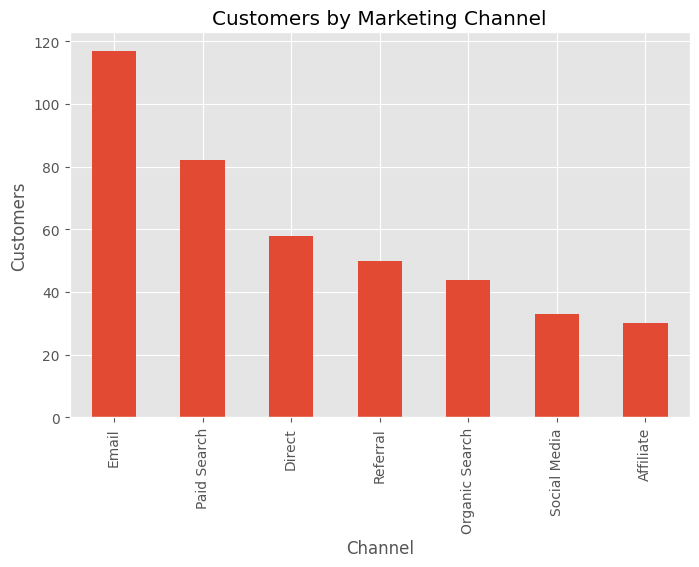

In [40]:
channel_customers = df.groupby("channel")["customers"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

channel_customers.plot(kind="bar")

plt.title("Customers by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Customers")

# Save chart
plt.savefig("channel_customers.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
from google.colab import files
files.download("channel_customers.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
funnel = {
    "Sessions": df["sessions"].sum(),
    "Leads": df["leads"].sum(),
    "MQLs": df["mqls"].sum(),
    "SQLs": df["sqls"].sum(),
    "Opportunities": df["opportunities"].sum(),
    "Customers": df["customers"].sum()
}

funnel

{'Sessions': np.int64(130028),
 'Leads': np.int64(7089),
 'MQLs': np.int64(3707),
 'SQLs': np.int64(1752),
 'Opportunities': np.int64(978),
 'Customers': np.int64(414)}

In [43]:
funnel_df = pd.DataFrame(
    list(funnel.items()),
    columns=["Stage", "Count"]
)

funnel_df

,Stage,Count
0,Sessions,130028
1,Leads,7089
2,MQLs,3707
3,SQLs,1752
4,Opportunities,978
5,Customers,414


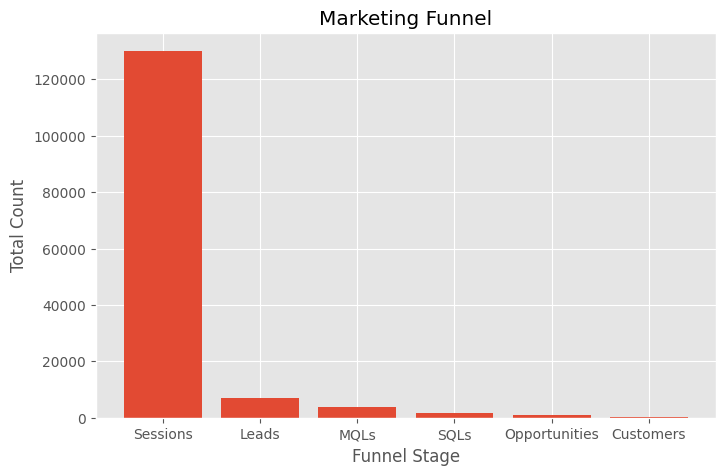

In [44]:
plt.figure(figsize=(8,5))

plt.bar(funnel_df["Stage"], funnel_df["Count"])

plt.title("Marketing Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Total Count")

plt.savefig("marketing_funnel.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
from google.colab import files
files.download("marketing_funnel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
session_to_lead = (funnel["Leads"]/funnel["Sessions"])*100

lead_to_mql = (funnel["MQLs"]/funnel["Leads"])*100

mql_to_sql = (funnel["SQLs"]/funnel["MQLs"])*100

sql_to_opp = (funnel["Opportunities"]/funnel["SQLs"])*100

opp_to_customer = (funnel["Customers"]/funnel["Opportunities"])*100

overall_conversion = (funnel["Customers"]/funnel["Sessions"])*100

In [47]:
print(f"Session → Lead : {session_to_lead:.2f}%")
print(f"Lead → MQL : {lead_to_mql:.2f}%")
print(f"MQL → SQL : {mql_to_sql:.2f}%")
print(f"SQL → Opportunity : {sql_to_opp:.2f}%")
print(f"Opportunity → Customer : {opp_to_customer:.2f}%")
print(f"Overall Conversion : {overall_conversion:.2f}%")

Session → Lead : 5.45%
Lead → MQL : 52.29%
MQL → SQL : 47.26%
SQL → Opportunity : 55.82%
Opportunity → Customer : 42.33%
Overall Conversion : 0.32%


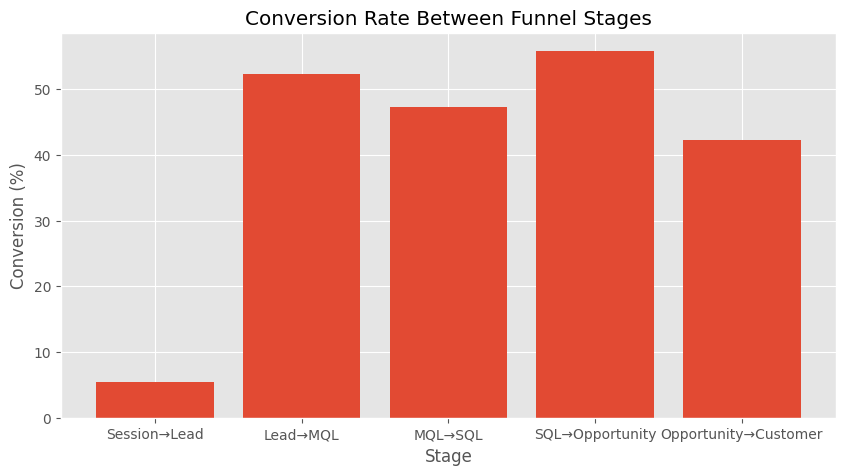

In [48]:
conversion = pd.DataFrame({
    "Stage":[
        "Session→Lead",
        "Lead→MQL",
        "MQL→SQL",
        "SQL→Opportunity",
        "Opportunity→Customer"
    ],
    "Conversion %":[
        session_to_lead,
        lead_to_mql,
        mql_to_sql,
        sql_to_opp,
        opp_to_customer
    ]
})

plt.figure(figsize=(10,5))

plt.bar(conversion["Stage"], conversion["Conversion %"])

plt.title("Conversion Rate Between Funnel Stages")
plt.xlabel("Stage")
plt.ylabel("Conversion (%)")

plt.savefig("conversion_rates.png", dpi=300, bbox_inches="tight")

plt.show()

In [49]:
from google.colab import files
files.download("conversion_rates.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
conversion["Drop Off %"] = 100 - conversion["Conversion %"]

conversion

,Stage,Conversion %,Drop Off %
0,Session→Lead,5.451903,94.548097
1,Lead→MQL,52.292284,47.707716
2,MQL→SQL,47.261937,52.738063
3,SQL→Opportunity,55.821918,44.178082
4,Opportunity→Customer,42.331288,57.668712


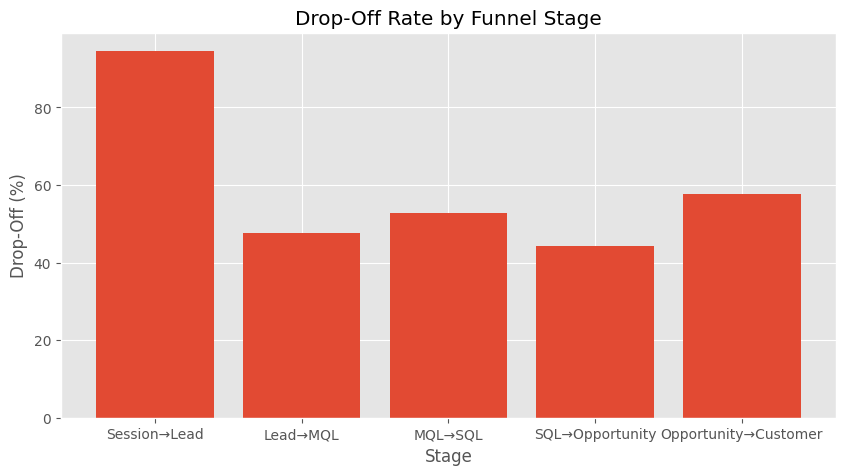

In [51]:
plt.figure(figsize=(10,5))

plt.bar(conversion["Stage"], conversion["Drop Off %"])

plt.title("Drop-Off Rate by Funnel Stage")
plt.xlabel("Stage")
plt.ylabel("Drop-Off (%)")

plt.savefig("dropoff_rate.png", dpi=300, bbox_inches="tight")

plt.show()

In [52]:
from google.colab import files
files.download("dropoff_rate.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

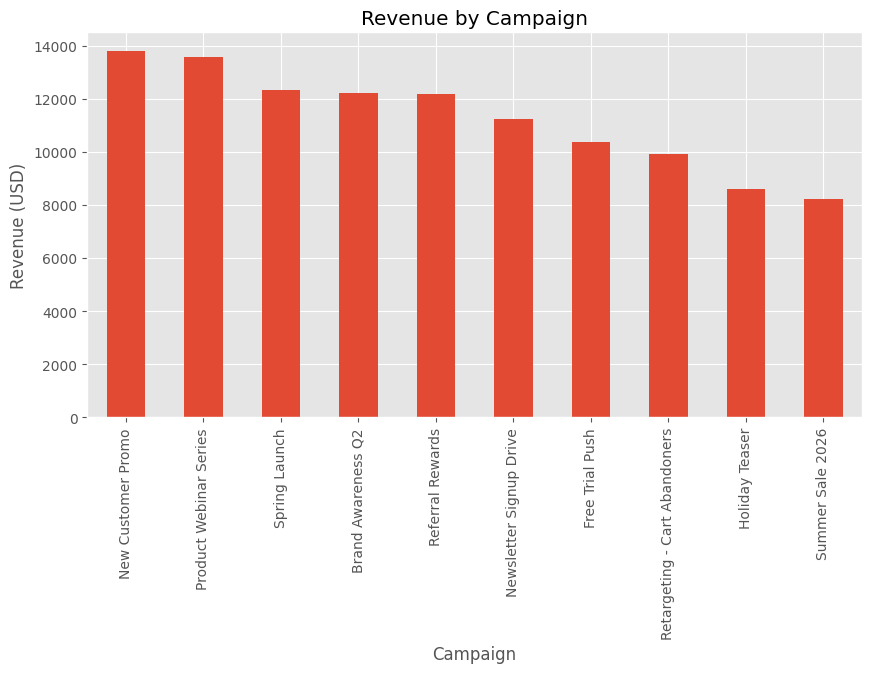

In [53]:
campaign_revenue = (
    df.groupby("campaign_name")["revenue_usd"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

campaign_revenue.plot(kind="bar")

plt.title("Revenue by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Revenue (USD)")

plt.savefig("campaign_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

In [55]:
from google.colab import files
files.download("campaign_revenue.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

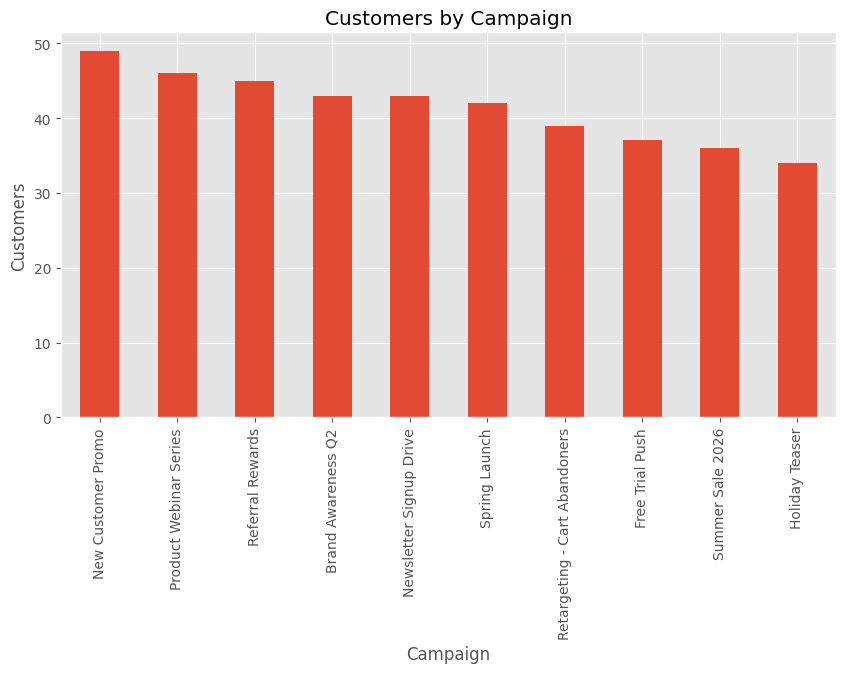

In [56]:
campaign_customers = (
    df.groupby("campaign_name")["customers"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

campaign_customers.plot(kind="bar")

plt.title("Customers by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Customers")

plt.savefig("campaign_customers.png", dpi=300, bbox_inches="tight")

plt.show()

In [57]:
from google.colab import files
files.download("campaign_customers.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

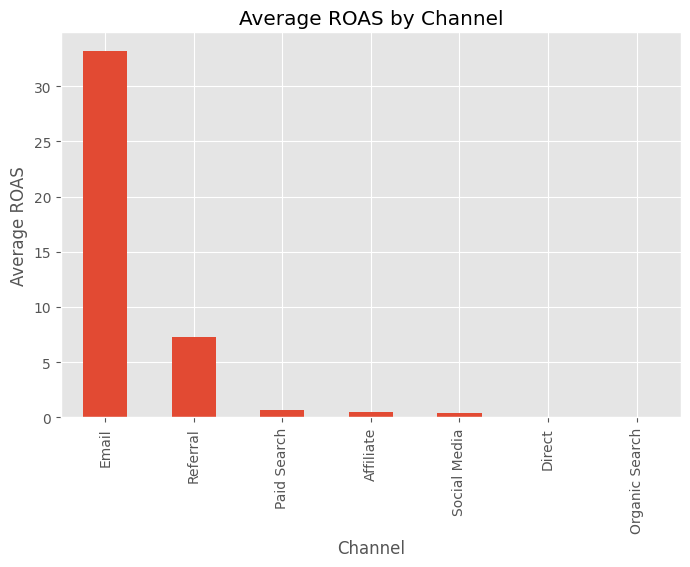

In [58]:
channel_roas = (
    df.groupby("channel")["roas"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

channel_roas.plot(kind="bar")

plt.title("Average ROAS by Channel")
plt.xlabel("Channel")
plt.ylabel("Average ROAS")

plt.savefig("roas_channel.png", dpi=300, bbox_inches="tight")

plt.show()

In [59]:
from google.colab import files
files.download("roas_channel.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>